In [1]:
import numpy as np
import pandas as pd

df = pd.read_csv(r"D:\netflix_python.csv")
df.head()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login,is_outlier
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12,0
1,2,John Miller,23,USA,Premium,300.00,Sci-Fi,2025-02-05,0
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24,0
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25,0
4,6,David Johnson,21,USA,Standard,300.00,Romance,2025-02-03,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17571 entries, 0 to 17570
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            17571 non-null  int64  
 1   Name               17571 non-null  object 
 2   Age                17571 non-null  int64  
 3   Country            17571 non-null  object 
 4   Subscription_Type  17571 non-null  object 
 5   Watch_Time_Hours   17571 non-null  float64
 6   Favorite_Genre     17571 non-null  object 
 7   Last_Login         17571 non-null  object 
 8   is_outlier         17571 non-null  int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 1.2+ MB


In [5]:
df.describe()

,User_ID,Age,Watch_Time_Hours,is_outlier
count,17571.000000,17571.000000,17571.000000,17571.0
mean,12502.247282,46.383871,237.415887,0.0
std,7221.595621,19.572444,92.659130,0.0
min,1.000000,13.000000,0.120000,0.0
25%,6217.000000,29.000000,180.740000,0.0
50%,12544.000000,46.000000,300.000000,0.0
75%,18762.500000,63.000000,300.000000,0.0
max,25000.000000,80.000000,300.000000,0.0


In [7]:
df.isnull().sum()

User_ID              0
Name                 0
Age                  0
Country              0
Subscription_Type    0
Watch_Time_Hours     0
Favorite_Genre       0
Last_Login           0
is_outlier           0
dtype: int64

In [9]:
subscription_type = df['Subscription_Type'].value_counts()
print(subscription_type)

Subscription_Type
Premium     5910
Basic       5856
Standard    5805
Name: count, dtype: int64


In [22]:
Avg_watch_time_by_country = df.groupby('Country')['Watch_Time_Hours'].mean().sort_values(ascending=False)
print(Avg_watch_time_by_country)

Country
France       243.004491
Canada       241.516453
Australia    240.155970
Brazil       239.004175
USA          237.314537
Mexico       237.304150
UK           236.922470
Germany      235.923139
India        232.398645
Japan        230.757344
Name: Watch_Time_Hours, dtype: float64


In [24]:
favourite_genre = df['Favorite_Genre'].value_counts()
print(favourite_genre)

Favorite_Genre
Horror         2594
Documentary    2551
Comedy         2516
Action         2515
Romance        2467
Drama          2466
Sci-Fi         2462
Name: count, dtype: int64


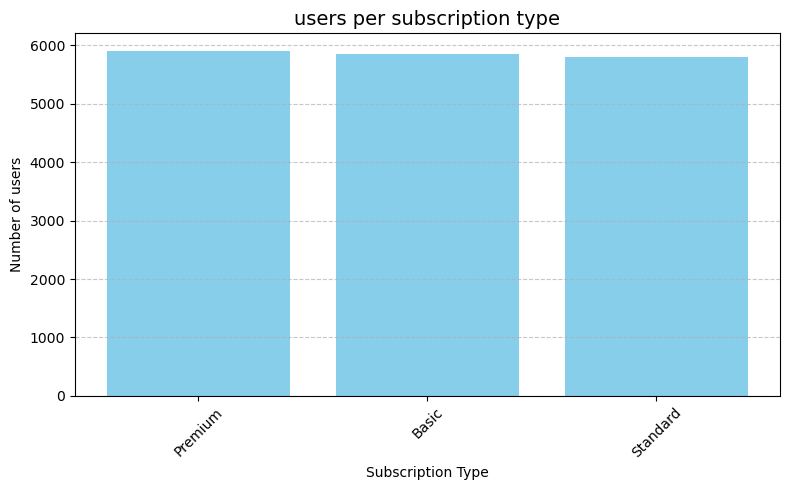

In [30]:
import matplotlib.pyplot as plt

# Count of users per subscription type
subscription_counts = df['Subscription_Type'].value_counts()

# Plotting the Bar Charts
plt.figure(figsize=(8, 5))
plt.bar(subscription_counts.index, subscription_counts.values, color='skyblue')
plt.title('users per subscription type', fontsize=14)
plt.xlabel('Subscription Type')
plt.ylabel('Number of users')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

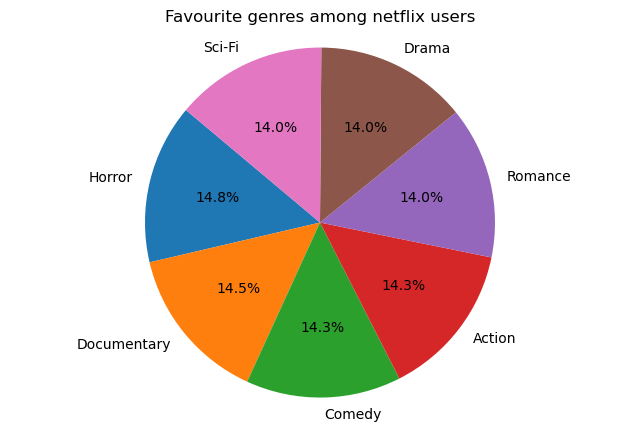

In [36]:
# Count of each favorite genre
genre_counts = df['Favorite_Genre'].value_counts()


plt.figure(figsize=(8, 5))
plt.pie(genre_counts, labels=genre_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Favourite genres among netflix users')
plt.axis('equal')
plt.show()


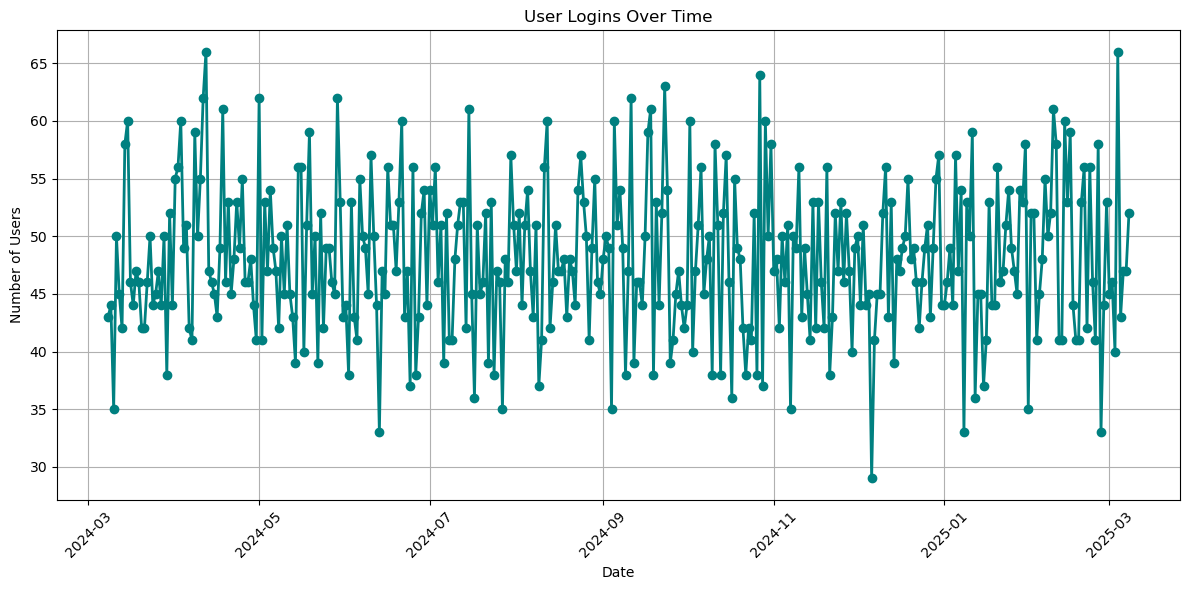

In [38]:
# Step 1: Convert 'Last_Login' to datetime
df['Last_Login'] = pd.to_datetime(df['Last_Login'])

# Step 2: Count users not logged in by date
login_counts = df['Last_Login'].value_counts().sort_index()

# Step 3: Plotting
plt.figure(figsize=(12, 6))
plt.plot(login_counts.index, login_counts.values, marker='o', color='teal', linewidth=2)
plt.title('User Logins Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()